In [85]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

### Retrieve data and build dataframse

In [87]:
from collections import defaultdict

PROJECT_PATH = "jdm8943-rochester-institute-of-technology/final-style-prompt-gen"

runs = api.runs(PROJECT_PATH)

rows_results  = []
rows_baseline = []

for run in runs:
    if run.state != "finished":
        continue

    datasource_data = defaultdict(dict)
    baseline_data   = defaultdict(dict)
    trial_metrics   = {}

    for k, v in run.summary.items():
        if k.startswith("_"):
            continue
        parts = k.split("/")
        if k.startswith("test/"):
            datasource_data[parts[1]][parts[2]] = v
        elif k.startswith("trial/"):
            trial_metrics[parts[1]] = v
        elif k.startswith("baseline/"):
            baseline_data[parts[1]][parts[2]] = v

    for datasource, metrics in datasource_data.items():
        rows_results.append({
            "run_name":        run.name,
            "test_datasource": datasource,
            **trial_metrics,
            **metrics,
        })

    for datasource, metrics in baseline_data.items():
        rows_baseline.append({
            "run_name":        run.name,
            "test_datasource": datasource,
            **metrics,
        })

results_df  = pd.DataFrame(rows_results)
baseline_df = pd.DataFrame(rows_baseline)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [88]:
results_df

,run_name,test_datasource,trainable_params,training_time_s,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,mean_cosine_sim,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,vec_norm_cv,vec_std,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,fanciful-snowball-5,expresso,133878029,3015.777347,0.916308,0.012650,0.914137,0.013370,0.918573,0.014788,0.492423,0.073821,0.040819,0.168720,20.813033,0.544521,0.377828,0.116217,0.792774,0.384183,0.083280,0.900,0.300000,0.653333,0.474740,0.474824,0.338076,0.493333,0.495491,0.604647,0.184669,0.935,0.246526,0.280952,0.342435,0.450000,0.497494,0.068021,0.540953,NaN,NaN,NaN,NaN
1,fanciful-snowball-5,styletalk,133878029,3015.777347,0.925050,0.013973,0.911717,0.016186,0.938821,0.012693,0.643797,0.076991,0.006461,0.012997,11.854404,0.878113,0.645657,0.097084,0.908670,0.505197,0.058181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.678393,0.278951,NaN,NaN,NaN,NaN,0.710000,0.446356,0.044225,0.273519,0.520000,0.419841,0.828333,0.366633
2,classic-surf-6,expresso,133878029,2973.095056,0.918968,0.012051,0.917457,0.012229,0.920576,0.015072,0.499808,0.073191,0.036087,0.127631,20.744247,0.503715,0.384486,0.108211,0.795937,0.391435,0.082512,0.850,0.357071,0.740000,0.438634,0.523900,0.307364,0.530000,0.499099,0.628750,0.179344,0.945,0.227980,0.331452,0.370670,0.395000,0.488851,0.092035,0.560496,NaN,NaN,NaN,NaN
3,classic-surf-6,styletalk,133878029,2973.095056,0.978239,0.013602,0.979126,0.012675,0.977372,0.015031,0.814631,0.113667,0.005000,0.008214,7.423232,0.921930,0.773496,0.126512,0.944748,0.744667,0.115875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676667,0.294222,NaN,NaN,NaN,NaN,0.710000,0.453762,0.012708,0.237346,0.485000,0.499775,0.835000,0.371181
4,azure-fog-7,expresso,133878029,3073.297493,0.916610,0.012258,0.914666,0.012696,0.918659,0.015105,0.490495,0.076271,0.038536,0.146663,21.290308,0.546502,0.376230,0.110859,0.805346,0.376858,0.084251,0.915,0.278882,0.643333,0.474353,0.463783,0.299746,0.475000,0.499375,0.595252,0.168587,0.950,0.217945,0.307643,0.358020,0.370000,0.482804,0.103996,0.523095,NaN,NaN,NaN,NaN
5,azure-fog-7,styletalk,133878029,3073.297493,0.921834,0.009942,0.895963,0.012173,0.949349,0.011820,0.635907,0.072495,0.043282,0.103724,12.017335,0.873233,0.587386,0.105080,0.765090,0.435334,0.063468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.717440,0.264716,NaN,NaN,NaN,NaN,0.723333,0.434754,0.035128,0.298105,0.614167,0.420508,0.831667,0.371181
6,charmed-waterfall-8,expresso,133878029,3094.164530,0.916502,0.011575,0.914409,0.011627,0.918686,0.014437,0.485780,0.073327,0.036399,0.151463,21.383016,0.575448,0.376047,0.106365,0.788906,0.374059,0.079282,0.845,0.361905,0.585000,0.492722,0.465288,0.290062,0.498333,0.498885,0.579769,0.173329,0.960,0.195959,0.306905,0.366865,0.398333,0.488419,0.005228,0.573752,NaN,NaN,NaN,NaN
7,charmed-waterfall-8,styletalk,133878029,3094.164530,0.921956,0.009876,0.903155,0.011165,0.941636,0.011942,0.628918,0.071361,0.015801,0.038674,12.068520,0.723084,0.568962,0.121155,0.881470,0.452046,0.060685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.692679,0.280316,NaN,NaN,NaN,NaN,0.716667,0.448144,0.012711,0.406336,0.552500,0.459341,0.831667,0.371181
8,effortless-snow-9,expresso,133878029,3104.523697,0.915922,0.011460,0.914038,0.011905,0.917896,0.014051,0.486436,0.071354,0.041177,0.167616,21.642574,0.578620,0.363059,0.104527,0.795745,0.368947,0.079836,0.895,0.306553,0.630000,0.482804,0.476859,0.294473,0.475000,0.499375,0.592066,0.173878,0.945,0.227980,0.310667,0.350916,0.378333,0.483824,0.029130,0.525925,NaN,NaN,NaN,NaN
9,effortless-snow-9,styletalk,133878029,3104.523697,0.965165,0.027285,0.9593

In [89]:
baseline_df

,run_name,test_datasource,bertscore_f1,bertscore_f1_std,bertscore_precision,bertscore_precision_std,bertscore_recall,bertscore_recall_std,chrf,chrf_std,dist1,dist2,inference_time_s,meteor,meteor_std,pred_semantic_sim,rougeL,rougeL_std,tag_f1_accent,tag_f1_accent_std,tag_f1_gender,tag_f1_gender_std,tag_f1_intrinsic_tags,tag_f1_intrinsic_tags_std,tag_f1_noise,tag_f1_noise_std,tag_f1_overall,tag_f1_overall_std,tag_f1_pitch,tag_f1_pitch_std,tag_f1_situational_tags,tag_f1_situational_tags_std,tag_f1_speaking_rate,tag_f1_speaking_rate_std,tag_f1_emotion,tag_f1_emotion_std,tag_f1_volume,tag_f1_volume_std
0,fanciful-snowball-5,expresso,0.897131,0.023512,0.896455,0.021826,0.897962,0.027585,0.396560,0.120120,0.085882,0.310303,151.643893,0.269766,0.119528,0.636589,0.299474,0.107327,0.685,0.464516,0.500000,0.500000,0.395170,0.331669,0.400000,0.489898,0.522557,0.244316,0.795,0.403702,0.449000,0.407512,0.383333,0.485054,NaN,NaN,NaN,NaN
1,fanciful-snowball-5,styletalk,0.885811,0.016622,0.869283,0.016258,0.903212,0.022240,0.296124,0.100778,0.104489,0.338019,144.735009,0.216898,0.129036,0.615458,0.229564,0.096404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.146500,0.239441,NaN,NaN,NaN,NaN,0.080000,0.271293,0.108333,0.309008,0.160,0.366606
2,classic-surf-6,expresso,0.905358,0.018158,0.903394,0.018082,0.907418,0.020270,0.438613,0.090568,0.075142,0.287609,146.988891,0.305540,0.110692,0.725234,0.333853,0.092858,0.730,0.443959,0.690000,0.462493,0.463663,0.324983,0.425000,0.494343,0.597481,0.203337,0.870,0.336303,0.510524,0.405459,0.330000,0.470213,NaN,NaN,NaN,NaN
3,classic-surf-6,styletalk,0.896234,0.022729,0.879911,0.024010,0.913354,0.024749,0.358105,0.132002,0.098922,0.329566,140.584725,0.271853,0.160928,0.653519,0.279951,0.124761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.275214,0.315956,NaN,NaN,NaN,NaN,0.285000,0.451414,0.163333,0.368164,0.250,0.433013
4,azure-fog-7,expresso,0.901576,0.023969,0.901219,0.023219,0.902083,0.027090,0.413925,0.117908,0.080545,0.289124,159.080168,0.287362,0.125833,0.675745,0.315186,0.108301,0.750,0.433013,0.670000,0.470213,0.427041,0.330998,0.400000,0.489898,0.560818,0.232189,0.840,0.366606,0.466119,0.412527,0.340000,0.473709,NaN,NaN,NaN,NaN
5,azure-fog-7,styletalk,0.889346,0.020727,0.873476,0.019922,0.905940,0.024272,0.313148,0.100871,0.082551,0.284887,151.991844,0.233717,0.122080,0.663928,0.248798,0.088384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.179833,0.261383,NaN,NaN,NaN,NaN,0.120000,0.324962,0.098333,0.295893,0.215,0.410822
6,charmed-waterfall-8,expresso,0.905813,0.017980,0.904403,0.017564,0.907311,0.020323,0.432801,0.088423,0.072093,0.267467,152.106700,0.296406,0.104632,0.728444,0.333741,0.088743,0.710,0.453762,0.625000,0.484123,0.448552,0.305436,0.435000,0.495757,0.586441,0.208501,0.895,0.306553,0.429738,0.406325,0.425000,0.494343,NaN,NaN,NaN,NaN
7,charmed-waterfall-8,styletalk,0.891617,0.019490,0.875074,0.018441,0.908952,0.023681,0.310514,0.113860,0.088835,0.287458,144.978999,0.248256,0.146400,0.676573,0.254679,0.104348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141000,0.248768,NaN,NaN,NaN,NaN,0.120000,0.324962,0.048333,0.211863,0.185,0.388298
8,effortless-snow-9,expresso,0.906322,0.017443,0.906275,0.017462,0.906485,0.020166,0.429915,0.092432,0.073224,0.273562,160.160216,0.299293,0.114584,0.741533,0.331493,0.088275,0.780,0.414246,0.683333,0.463980,0.416948,0.321154,0.393333,0.487351,0.591388,0.203324,0.920,0.271293,0.496286,0.412683,0.360000,0.480000,NaN,NaN,NaN,NaN
9,effortless-snow-9,styletalk,0.890358,0.018723,0.875318,0.019309,0.906079,0.021630,0.306990,0.100939,0.078393,0.279632,152.923487,0.230841,0.122705,0.688291,0.244372,0.095671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157333,0.265438,NaN,NaN,NaN,NaN,0.148333,0.353864,0.116667,0.317543,0.115,0.319022


In [90]:
def summarize(df, group_cols):
    drop_std_cols = [c for c in df.columns if c.endswith("_std")]
    agg_df = df.drop(columns=["run_name"] + drop_std_cols, errors="ignore")
    return agg_df.groupby(group_cols).agg(["mean", "std"]).round(4)

results_summary  = summarize(results_df,  ["test_datasource"])
baseline_summary = summarize(baseline_df, ["test_datasource"])


In [91]:
results_summary

trainable_params      training_time_s          bertscore_f1  \
                            mean  std            mean      std         mean   
test_datasource                                                               
expresso             133878029.0  0.0       3052.1716  55.9645       0.9169   
styletalk            133878029.0  0.0       3052.1716  55.9645       0.9424   

                        bertscore_precision         bertscore_recall          \
                    std                mean     std             mean     std   
test_datasource                                                                
expresso         0.0012              0.9149  0.0014           0.9189  0.0010   
styletalk        0.0271              0.9299  0.0370           0.9557  0.0176   

                   chrf           dist1           dist2          \
                   mean     std    mean     std    mean     std   
test_datasource                                                   
expresso         0.4910  0.0057  0.0386  0.0024  0.1524  0.0169   
styletalk        0.6994  0.0879  0.0225  0.0188  0.0506  0.0439   

                inference_time_s         mean_cosine_sim          meteor  \
                            mean     std            mean     std    mean   
test_datasource                                                            
expresso                 21.1746  0.3846          0.5498  0.0302  0.3755   
styletalk                11.0815  2.0468          0.8303  0.0861  0.6591   

                        pred_semantic_sim          rougeL          \
                    std              mean     std    mean     std   
test_datasource                                                     
expresso         0.0078            0.7957  0.0061  0.3791  0.0088   
styletalk        0.0869            0.8742  0.0673  0.5616  0.1384   

                tag_f1_accent         tag_f1_gender          \
                         mean     std          mean     std   
test_datasource                                               
expresso                0.881  0.0315        0.6503  0.0565   
styletalk                 NaN     NaN           NaN     NaN   

                tag_f1_intrinsic_tags         tag_f1_noise          \
                                 mean     std         mean     std   
test_datasource                                                      
expresso                       0.4809  0.0247       0.4943  0.0226   
styletalk                         NaN     NaN          NaN     NaN   

                tag_f1_overall         tag_f1_pitch          \
                          mean     std         mean     std   
test_datasource                                               
expresso                0.6001  0.0183        0.947  0.0091   
styletalk               0.6913  0.0163          NaN     NaN   

                tag_f1_situational_tags        tag_f1_speaking_rate          \
                                   mean    std                 mean     std   
test_datasource                                                               
expresso                         0.3075  0.018               0.3983  0.0312   
styletalk                           NaN    NaN               0.7127  0.0076   

                vec_norm_cv         tag_f1_emotion         tag_f1_volume  \
                       mean     std           mean     std          mean   
test_datasource                                                            
expresso             0.0597  0.0418            NaN     NaN           NaN   
styletalk            0.0324  0.0197         0.5427  0.0476         0.832   

                         
                    std  
test_datasource          
expresso            NaN  
styletalk        0.0025

In [92]:
baseline_summary

bertscore_f1         bertscore_precision          \
                        mean     std                mean     std   
test_datasource                                                    
expresso              0.9032  0.0039              0.9023  0.0038   
styletalk             0.8907  0.0038              0.8746  0.0038   

                bertscore_recall            chrf           dist1          \
                            mean     std    mean     std    mean     std   
test_datasource                                                            
expresso                  0.9043  0.0041  0.4224  0.0171  0.0774  0.0058   
styletalk                 0.9075  0.0038  0.3170  0.0239  0.0906  0.0109   

                  dist2         inference_time_s          meteor          \
                   mean     std             mean     std    mean     std   
test_datasource                                                            
expresso         0.2856  0.0166         153.9960  5.5238  0.2917  0.0139   
styletalk        0.3039  0.0276         147.0428  5.2528  0.2403  0.0209   

                pred_semantic_sim          rougeL         tag_f1_accent  \
                             mean     std    mean     std          mean   
test_datasource                                                           
expresso                   0.7015  0.0441  0.3227  0.0152         0.731   
styletalk                  0.6596  0.0279  0.2515  0.0184           NaN   

                        tag_f1_gender         tag_f1_intrinsic_tags          \
                    std          mean     std                  mean     std   
test_datasource                                                               
expresso         0.0365        0.6337  0.0789                0.4303  0.0268   
styletalk           NaN           NaN     NaN                   NaN     NaN   

                tag_f1_noise         tag_f1_overall         tag_f1_pitch  \
                        mean     std           mean     std         mean   
test_datasource                                                            
expresso              0.4107  0.0182         0.5717  0.0308        0.864   
styletalk                NaN     NaN         0.1800  0.0553          NaN   

                        tag_f1_situational_tags         tag_f1_speaking_rate  \
                    std                    mean     std                 mean   
test_datasource                                                                
expresso         0.0487                  0.4703  0.0332               0.3677   
styletalk           NaN                     NaN     NaN               0.1507   

                        tag_f1_emotion         tag_f1_volume          
                    std           mean     std          mean     std  
test_datasource                                                       
expresso         0.0380            NaN     NaN           NaN     NaN  
styletalk        0.0789          0.107  0.0412         0.185  0.0516

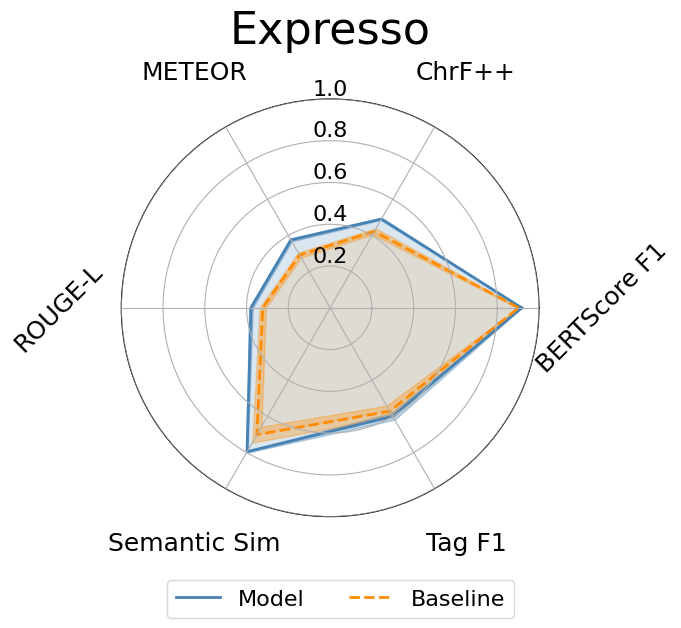

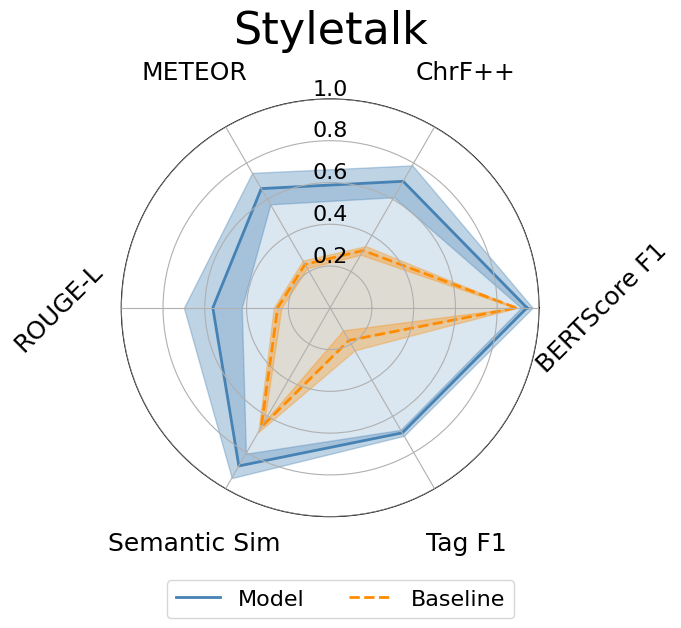

In [93]:
import numpy as np

METRICS = {
    "BERTScore F1": "bertscore_f1",
    "ChrF++": "chrf",
    "METEOR": "meteor",
    "ROUGE-L": "rougeL",
    "Semantic Sim": "pred_semantic_sim",
    "Tag F1": "tag_f1_overall",
}




def radar_plot(datasource, results_summary, baseline_summary):
    labels = list(METRICS.keys())
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    def get_vals(summary_df):
        row = summary_df.loc[datasource]
        means = [float(row[(col, "mean")]) for col in METRICS.values()]
        stds  = [float(row[(col, "std")])  for col in METRICS.values()]
        return means + means[:1], stds + stds[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.set_axisbelow(False)


    test_vals, test_stds   = get_vals(results_summary)
    base_vals, base_stds   = get_vals(baseline_summary)

    test_vals  = np.array(test_vals);  test_stds  = np.array(test_stds)
    base_vals  = np.array(base_vals);  base_stds  = np.array(base_stds)

    h1, = ax.plot(angles, test_vals, color="steelblue", linewidth=2, label="Model")
    ax.fill_between(angles, test_vals - test_stds, test_vals + test_stds,
                    color="steelblue", alpha=0.35)
    ax.fill(angles, test_vals, color="steelblue", alpha=0.2)

    h2, = ax.plot(angles, base_vals, color="darkorange", linewidth=2, linestyle="--", label="Baseline")
    ax.fill_between(angles, base_vals - base_stds, base_vals + base_stds,
                    color="darkorange", alpha=0.32)
    ax.fill(angles, base_vals, color="darkorange", alpha=0.12)


    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])  # suppress auto labels

    for i, (angle, label) in enumerate(zip(angles[:-1], labels)):
        rotation = 45 if i == 0 or i==3 else 0
        ax.text(angle, 1.3, label,
                ha='center', va='center',
                rotation=rotation, fontsize=18,
                transform=ax.get_xaxis_transform())


    ax.set_ylim(0, 1)
    ax.set_rlabel_position(90)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('center')

    ax.set_title(datasource.capitalize(), size=32, pad=40)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', pad=34)


    fig.legend(handles=[h1, h2], loc="lower center", ncol=2,
               fontsize=16, bbox_to_anchor=(0.5, -0.08), frameon=True)

    fig.subplots_adjust(top=0.75)

    plt.tight_layout()
    plt.show()

for ds in ["expresso", "styletalk"]:
    radar_plot(ds, results_summary, baseline_summary)


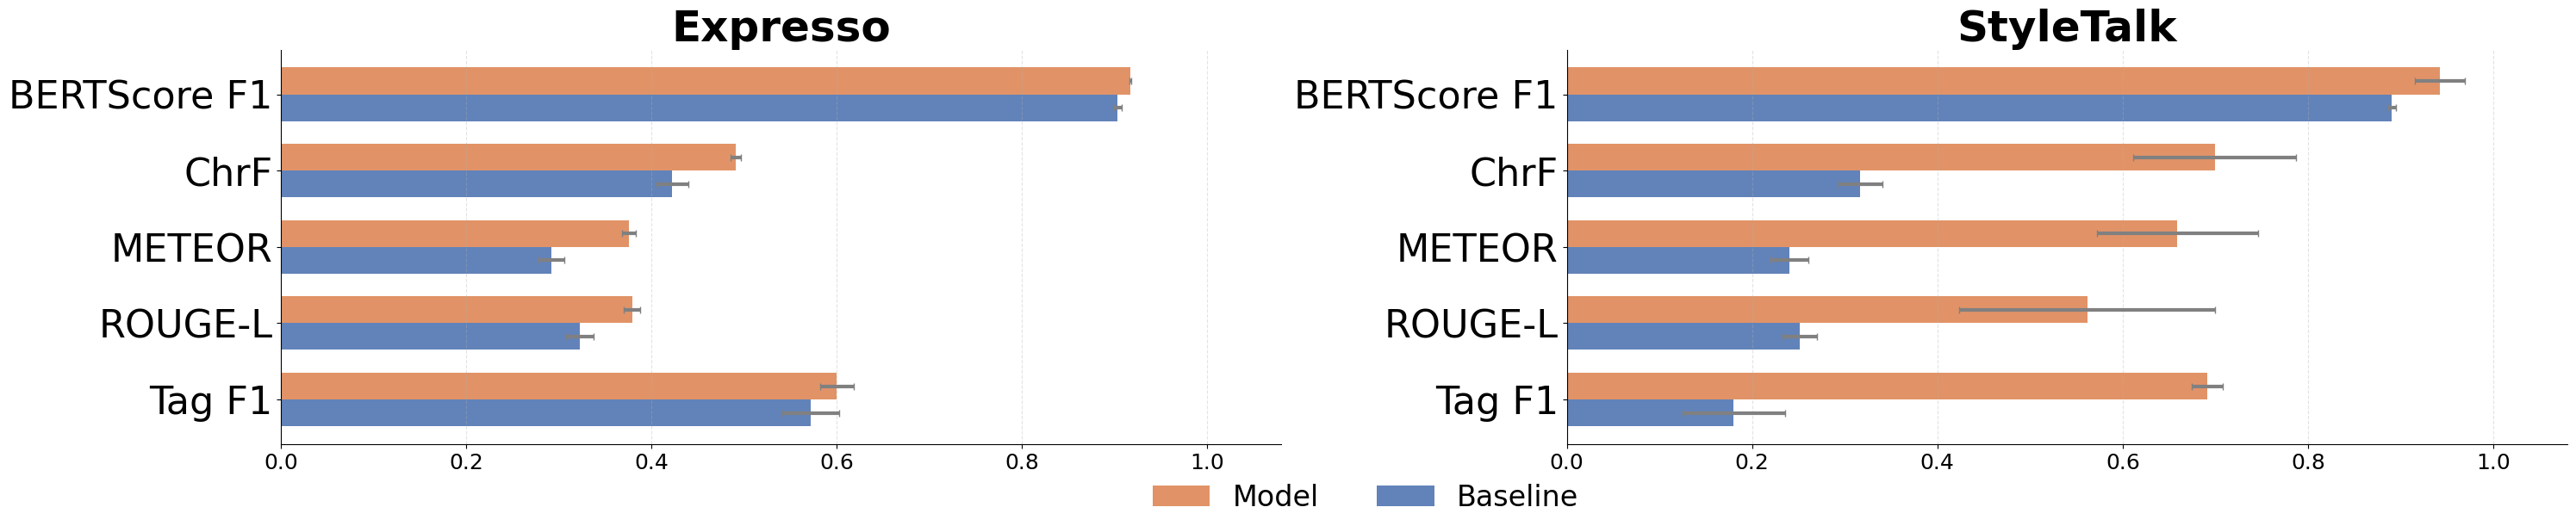

In [94]:
import numpy as np

METRICS = {
    "expresso": [
        ("bertscore_f1",         "BERTScore F1"),
        ("chrf",                 "ChrF"),
        ("meteor",               "METEOR"),
        ("rougeL",               "ROUGE-L"),
        ("tag_f1_overall",       "Tag F1"),
    ],
    "styletalk": [
        ("bertscore_f1",         "BERTScore F1"),
        ("chrf",                 "ChrF"),
        ("meteor",               "METEOR"),
        ("rougeL",               "ROUGE-L"),
        ("tag_f1_overall",       "Tag F1")
    ],
}

FONT = {
    "title":       36,
    "suptitle":    36,
    "axis_label":  22,
    "tick_label":  32,
    "legend":      24,
    "x_tick":      18,

}

DATASET_LABELS = {"expresso": "Expresso", "styletalk": "StyleTalk"}
BASELINE_COLOR    = "#4C72B0"
MODEL_COLOR = "#DD8452"

fig, axes = plt.subplots(1, 2, figsize=(30, 6), sharey=False)

for ax, (dataset, metric_pairs) in zip(axes, METRICS.items()):
    keys   = [k   for k, _   in metric_pairs]
    labels = [lbl for _, lbl in metric_pairs]

    model_means, model_stds = [], []
    base_means,  base_stds  = [], []

    for key in keys:
        def _get(summary, ds, col, stat):
            try:
                return float(summary.loc[ds, (col, stat)])
            except KeyError:
                return float("nan")

        model_means.append(_get(results_summary,  dataset, key, "mean"))
        model_stds .append(_get(results_summary,  dataset, key, "std"))
        base_means .append(_get(baseline_summary, dataset, key, "mean"))
        base_stds  .append(_get(baseline_summary, dataset, key, "std"))

    n     = len(keys)
    y     = np.arange(n)
    bar_h = 0.35

    ax.barh(y - bar_h / 2, model_means, bar_h,
            xerr=model_stds, label="Model",
            color=MODEL_COLOR, alpha=0.88,
            error_kw=dict(elinewidth=3, capsize=3, ecolor="grey"))
    ax.barh(y + bar_h / 2, base_means, bar_h,
            xerr=base_stds, label="Baseline",
            color=BASELINE_COLOR, alpha=0.88,
            error_kw=dict(elinewidth=3, capsize=3, ecolor="grey"))

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=FONT["tick_label"])
    # ax.set_xlabel("Score",     fontsize=FONT["axis_label"])
    ax.tick_params(axis="x", labelsize=FONT["x_tick"])

    ax.set_title(DATASET_LABELS[dataset], fontsize=FONT["title"], fontweight="semibold")
    ax.set_xlim(0, 1.08)
    ax.invert_yaxis()
    
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=FONT["legend"], frameon=False,
           bbox_to_anchor=(0.53, -0.05))

# fig.suptitle("Model vs Baseline — Per Dataset", fontsize=FONT["suptitle"], fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()


In [95]:
# radar plot? good for many metrics

In [96]:
# GPU usage metrics
power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocatedBytes"

SMOOTH_SPAN = 10

def smooth(s, span=SMOOTH_SPAN):
    return s.dropna().reset_index(drop=True).ewm(span=span, min_periods=1).mean()

sys_data = {}
seen_runs = set()

for run in api.runs(PROJECT_PATH):
    if run.state != "finished" or run.name in seen_runs:
        continue
    seen_runs.add(run.name)
    full_run = api.run("/".join(run.path))
    df = pd.DataFrame(full_run.history(stream="system"))
    if not df.empty:
        sys_data[run.name] = df

print(f"Fetched system history for {len(sys_data)} run(s)")
print("Available GPU columns:", [c for c in next(iter(sys_data.values())).columns if "gpu" in c.lower()])

## not finished for poster, need to redo while separating for baseline, test


Fetched system history for 5 run(s)
Available GPU columns: ['system.gpu.0.correctedMemoryErrors', 'system.gpu.0.enforcedPowerLimitWatts', 'system.gpu.0.gpu', 'system.gpu.0.memory', 'system.gpu.0.memoryAllocated', 'system.gpu.0.memoryAllocatedBytes', 'system.gpu.0.memoryClock', 'system.gpu.0.powerPercent', 'system.gpu.0.powerWatts', 'system.gpu.0.smClock', 'system.gpu.0.temp', 'system.gpu.0.uncorrectedMemoryErrors']
